# Setup the environment
Run the following two blocks to set up the environment.

In [2]:
!git clone https://github.com/HaizhouZ/lab4_student
%cd lab4_student

Cloning into 'lab4_student'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 30 (delta 0), reused 30 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (30/30), 136.54 KiB | 8.03 MiB/s, done.
/content/lab4_student


After running the following install command, **restart the notebook session**. Then start the lab4 main part

In [3]:
!pip install -e ".[dev]"

Obtaining file:///content/lab4_student
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 77.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.8/740.8 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 12.3 MB/s eta 0:00:00
  Building editable for lab4-catch (pyproject.toml) ... done
  Created wheel for lab4-catch: filename=lab4_catch-0.1.0-0.editable-py3-none-any.whl size=2943 sha256=2e57eed8e52160576359f64dd08cd841e0979740f41ecdcec375c3cb0e6b5f03
  Stored in directory: /tmp/pip-ephem-wheel-cache-joxcjrru/wheels/f1/cc/0c/d2f72f12ddc549d7fc723aa3845711c825d6ad39bc81a19a74
Successfully built lab4-catch


# Lab 4

In [1]:
%cd lab4_student
# run this block if you are not in the lab4 folder

/content/lab4_student


In [2]:
import numpy as np
import os
os.environ['MUJOCO_GL'] = 'egl'
import mujoco
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
from pathlib import Path

from lab4.catch_controller import (
    CatchConfig,
    CatchController,
    TargetSource,
    TaskSpaceGains,
    run_catch_loop,
)

def find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / 'rsc' / 'planar3' / 'scene.xml').exists() and (parent / 'src').exists():
            return parent
    raise FileNotFoundError('Could not find repo root from current working directory')


repo_root = find_repo_root(Path.cwd())
scene_path = repo_root / 'rsc' / 'planar3' / 'scene.xml'

mj_model = mujoco.MjModel.from_xml_path(str(scene_path))

renderer = mujoco.Renderer(mj_model, width=640, height=480)
frames = []

def capture_step(model: mujoco.MjModel, data: mujoco.MjData, step_index: int) -> None:
    if step_index % RENDER_STRIDE == 0:
        renderer.update_scene(data)
        frames.append(renderer.render().copy())

## Understanding the Kinematics

### Coordinates

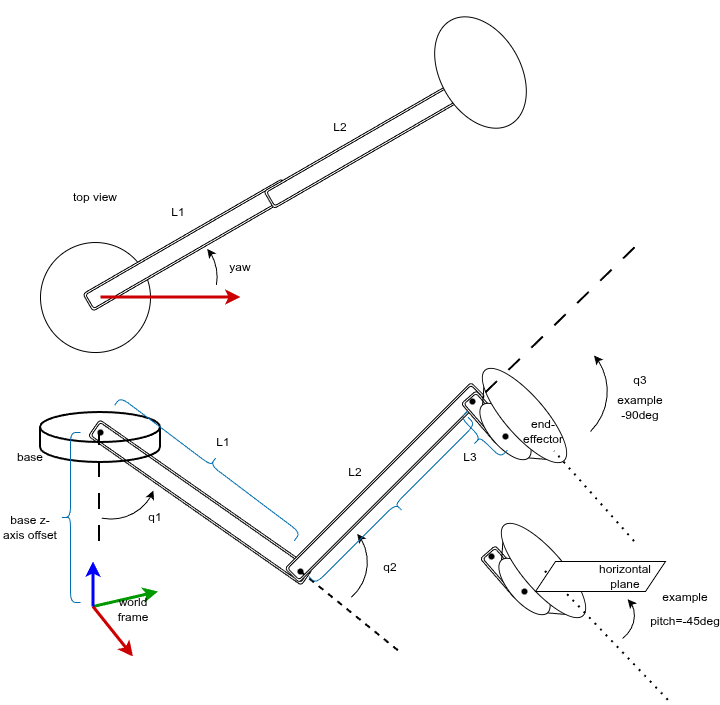

the zero joint angle configuration corresponds to:
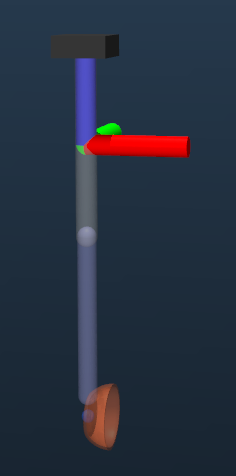


 the forward kinematics model follows these steps:

 1. **Coordinate Transformation (Link Angles)**: The code maps $q_1 = 0$ to a vertical "down" position. The subsequent angles $t_i$ represent the absolute pitch of each link relative to the horizontal plane:$$t_1 = q_1 - \frac{\pi}{2}$$$$t_2 = t_1 + q_2$$$$t_3 = t_2 + q_3$$
 2. **Radial Reach and Height**: The total radial distance $r$ (projection on the XY plane) and the height $z$ are calculated using the sum of the link projections:$$r = \sum_{i=1}^{3} l_i \cos(t_i)$$$$z = z_{\text{base}} + \sum_{i=1}^{3} l_i \sin(t_i)$$
 3. **3D Mapping**: Finally, the reach is decomposed into $x$ and $y$ using the $yaw$ angle, and the end-effector pitch $\phi$ is assigned the absolute angle of the final link:$$x = r \cos(\text{yaw})$$$$y = r \sin(\text{yaw})$$$$\phi = t_3$$

## Student Implementation

In [3]:
class StudentCatchController(CatchController):
  def __init__(self, q_home: np.ndarray, gains: TaskSpaceGains, catch_cfg: CatchConfig) -> None:
      super().__init__(q_home, gains, catch_cfg)

  def task_jacobian(self, q: np.ndarray) -> np.ndarray:
    """
    student todo: Computes the 4x4 analytic Jacobian for the planar robot.
    Rows: [dx, dy, dz, dphi]
    Cols: [dq_yaw, dq1, dq2, dq3]
    """
    yaw, q1, q2, q3 = q
    l1, l2, l3 = self.link_lengths

    t1 = q1 - np.pi / 2
    t2 = t1 + q2
    t3 = t2 + q3

    r = l1 * np.cos(t1) + l2 * np.cos(t2) + l3 * np.cos(t3)

    dr_dq1 = -l1 * np.sin(t1) - l2 * np.sin(t2) - l3 * np.sin(t3)
    dr_dq2 = -l2 * np.sin(t2) - l3 * np.sin(t3)
    dr_dq3 = -l3 * np.sin(t3)

    dz_dq1 =  l1 * np.cos(t1) + l2 * np.cos(t2) + l3 * np.cos(t3)
    dz_dq2 =  l2 * np.cos(t2) + l3 * np.cos(t3)
    dz_dq3 =  l3 * np.cos(t3)

    J = np.array([
        [-r * np.sin(yaw), np.cos(yaw) * dr_dq1, np.cos(yaw) * dr_dq2, np.cos(yaw) * dr_dq3],
        [ r * np.cos(yaw), np.sin(yaw) * dr_dq1, np.sin(yaw) * dr_dq2, np.sin(yaw) * dr_dq3],
        [0.0,               dz_dq1,               dz_dq2,               dz_dq3],
        [0.0,               1.0,                  1.0,                  1.0],
    ])

    return J

  def _compute_task_space_tau(
        self,
        jacobian: np.ndarray,
        pos_err: np.ndarray,
        vel_err: np.ndarray,
        phi_err: float,
        phi_vel_err: float,
        mass_matrix: np.ndarray,
        nonlinear_effects: np.ndarray,
    ) -> tuple[np.ndarray, np.ndarray]:
        """
        student todo: implement task-space PD control and inverse-dynamics mapping.
        return (tau, qdd_des).
        """
        # 1) build task-space position/orientation error vector
        task_err = np.concatenate([pos_err, [phi_err]])

        # 2) build task-space velocity error vector
        task_rate_err = np.concatenate([vel_err, [phi_vel_err]])

        # 3) PD law in task-space to get desired task acceleration
        task_acc_cmd = (self.gains.kp * task_err) + (self.gains.kd * task_rate_err)

        # 4) map task acceleration to joint acceleration
        qdd_des = self._solve_for_qdd(jacobian, task_acc_cmd)

        # 5) use the inverse dynamics to compute tau
        tau = (mass_matrix @ qdd_des) + nonlinear_effects

        return tau, qdd_des

########## studnet job: change the initial states
q_home = np.array([1.0, 0, 2.0, -1.6], dtype=float)
########### student job: tune the task-space gains
gains = TaskSpaceGains.from_scalars(200.0, 20.0)
########### student job: tune the joint-space gains
gains.nominal_kp = 200.0
gains.nominal_kd = 20.0

catch_cfg = CatchConfig(bowl_z_offset=0.02, high_error_threshold=1.5)
controller = StudentCatchController(q_home=q_home, gains=gains, catch_cfg=catch_cfg)

## Jacobian Test
The following code can help you test your `task_jacobian`. It solves an inverse kinematics using gradient descent (i.e., the acc)

In [4]:
######## test your task-space jacobian
if True:
  target = np.array([0.3, 0.1, 0.0, 0.0]) # test target (x,y,z,phi)
  q = np.zeros(4)
  tolerance = 1e-5
  for i in range(100):
      # compute current jacobian
      jac = controller.task_jacobian(q)
      # compute current task space pose
      x,y,z,phi = controller.forward_kinematics(q)
      # compute desired task space acceleration
      acc = 0.1 * (target - np.array([x,y,z,phi]))
      q += controller._solve_for_qdd(jac, acc)
  if np.linalg.norm(acc) < tolerance:
    print("Jacobian test passed")
    print("q", q)


Jacobian test passed
q [ 0.32175056  0.08079844  2.08782125 -0.5978651 ]


## Catch Test

In [5]:
SIM_SECONDS = 2.0
FPS = 30

RENDER_STRIDE = max(1, int(round(1.0 / (FPS * mj_model.opt.timestep))))
frames.clear()
mj_data = mujoco.MjData(mj_model)
run_catch_loop(
    mj_model=mj_model,
    mj_data=mj_data,
    controller=controller,
    joint_names=['base_yaw', 'joint1', 'joint2', 'joint3'],
    ee_site_name='ee_site',
    source=TargetSource.OBJECT,
    object_body_name='catch_object',
    actuator_names=None,
    sim_seconds=SIM_SECONDS,
    step_callback=capture_step,
)

print(f'Frames captured: {len(frames)}')

if not frames:
    raise RuntimeError('No frames captured. Increase SIM_SECONDS or inspect setup.')

interval_ms = 1000.0 * mj_model.opt.timestep * RENDER_STRIDE

fig, ax = plt.subplots(figsize=(8, 6))
ax.axis('off')
img = ax.imshow(frames[0])


def update(i):
    img.set_data(frames[i])
    return (img,)


anim = FuncAnimation(fig, update, frames=len(frames), interval=interval_ms, blit=True)
display(HTML(anim.to_jshtml()))
plt.close(fig)

Frames captured: 58
